In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
park_agg = pd.read_csv("../data/clean/park_agg.csv")
park_agg.head()


,Park Name,Recreation Visits,Non Recreation Visits,Recreation Hours,Non Recreation Hours,Concessioner Lodging,Concessioner Camping,Tent Campers,RV Campers,Backcountry,Non Recreation Overnight Stays,Miscellaneous Overnight Stays,Number of Activities,Entrance Fees
0,Acadia NP,297181.590909,3925.000000,1.931537e+06,3925.000000,0.000000,104.825758,10320.848485,3754.424242,106.265152,0.0,698.704545,46.0,6.0
1,Arches NP,127372.462121,125.484848,5.245314e+05,125.484848,0.000000,0.000000,1339.030303,1406.000000,32.174242,0.0,457.840909,18.0,30.0
2,Badlands NP,86726.174242,5311.272727,3.805244e+05,5311.272727,802.356061,2125.492424,325.030303,72.454545,192.409091,0.0,6.598485,21.0,30.0
3,Big Bend NP,39713.340909,207.181818,8.469260e+05,207.181818,2717.181818,616.053030,4288.750000,2258.462121,3197.219697,0.0,2354.234848,24.0,30.0
4,Biscayne NP,45659.689394,0.000000,1.457889e+05,0.000000,0.000000,0.000000,128.962121,0.000000,0.000000,0.0,238.113636,24.0,0.0


[0.36904341 0.19660692]


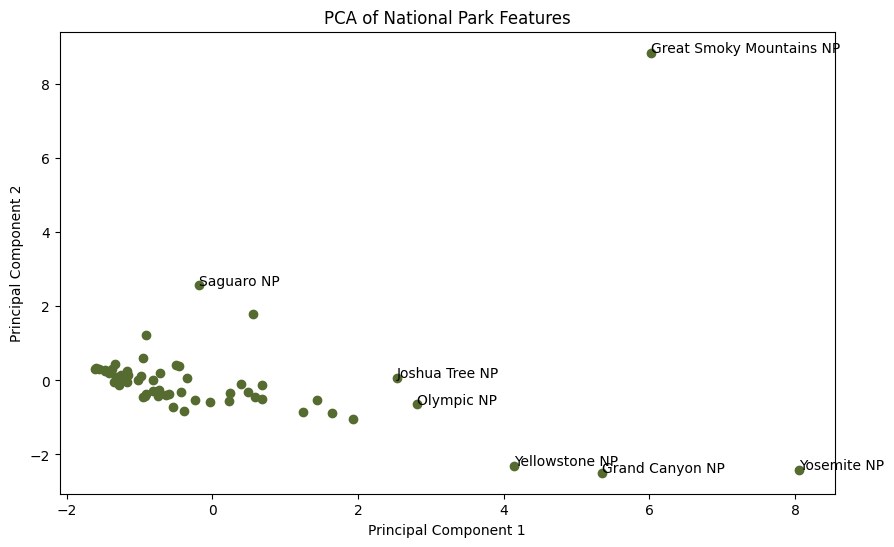

In [ ]:
pca_feat = ['Non Recreation Visits','Non Recreation Hours','Concessioner Lodging','Concessioner Camping','Tent Campers','RV Campers','Backcountry',
'Miscellaneous Overnight Stays','Number of Activities','Entrance Fees'] #features to test
x = park_agg[pca_feat]
x_scaled = StandardScaler().fit_transform(x)
pca = PCA(n_components=2)
prin_comp = pca.fit_transform(x_scaled)
pca_df = pd.DataFrame(prin_comp,columns=['PC1', 'PC2'])
pca_df['Park Name'] = park_agg['Park Name']
print(pca.explained_variance_ratio_)
print(pca_df.head())
#plot
plt.figure(figsize=(10,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], color ='darkolivegreen')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of National Park Features')

for i, park in enumerate(pca_df['Park Name']):
    if abs(pca_df['PC1'][i]) > 2 or abs(pca_df['PC2'][i]) > 2:
        plt.annotate(park,(pca_df['PC1'][i], pca_df['PC2'][i]))

In [18]:
print(pca.explained_variance_ratio_)
pca.components_
ldgs = pd.DataFrame(pca.components_.T,columns=['PC1','PC2'],index=pca_feat)
print(ldgs)

[0.36904341 0.19660692]
                                    PC1       PC2
Non Recreation Visits          0.234020  0.605588
Non Recreation Hours           0.234020  0.605588
Concessioner Lodging           0.405842 -0.302337
Concessioner Camping           0.166119 -0.179989
Tent Campers                   0.453542 -0.040321
RV Campers                     0.456753 -0.005685
Backcountry                    0.397992 -0.114050
Miscellaneous Overnight Stays  0.206190  0.138725
Number of Activities           0.165073 -0.132682
Entrance Fees                  0.235970 -0.302008


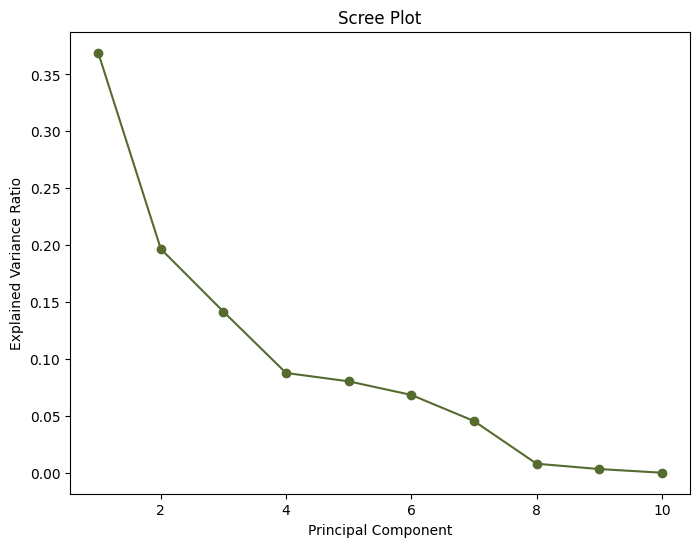

In [26]:
pca = PCA()
pca.fit(x_scaled)
plt.figure(figsize=(8,6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),pca.explained_variance_ratio_,marker='o', color='darkolivegreen')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()